## **Gradient Descent**

#### **Import Libraries**

In [2]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

### **Generate Synthetic Regression Dataset**

In [13]:
# Dataset with 100 samples and 1 feature.
X,y = make_regression(
    n_samples=100,
    n_features=1,
    n_informative=1,
    n_targets=1,
    noise=20,
    random_state=13
)

### **Visualize the Dataset**

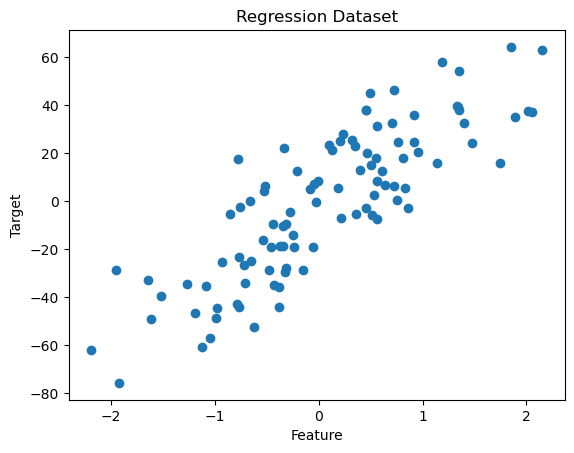

In [4]:
plt.scatter(X,y)
plt.title("Regression Dataset")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.show()

### **Split Data into Train and Test Sets**

In [5]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

## **Import Linear Regression**

In [6]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

## **Train the Model**

In [7]:
lr.fit(X_train,y_train)

print(lr.coef_)
print(lr.intercept_)

[28.12597332]
-2.271014426178382


- The model learned slope (m) and intercept (b) from the training data.

## **Predict on Test Data**

In [8]:
y_pred = lr.predict(X_test)

from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6345158782661013

### **Implement Gradient Descent From Scratch**

In [9]:
class GDRegressor:
    
    def __init__(self,learning_rate,epochs):
        
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs
        
    def fit(self,X,y):
        
        for i in range(self.epochs):
            
            loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
            
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)*X.ravel())
            
            self.b = self.b - (self.lr * loss_slope_b)
            
            self.m = self.m - (self.lr * loss_slope_m)
            
        print(self.m,self.b)
        
        
    def predict(self,X):
        
        return self.m * X + self.b

In [10]:
gd = GDRegressor(0.001,50)

- Model initialized with learning rate 0.001 and 50 iterations.

In [11]:
gd.fit(X_train,y_train)

28.159367347119066 -2.3004574196824854


- Gradient Descent updates parameters until the best slope and intercept are found.

In [12]:
y_pred = gd.predict(X_test)

from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6343842836315579

- Gradient Descent model achieves performance close to sklearn Linear Regression.